In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("Libraries loaded")

Libraries loaded


In [2]:
rfm = pd.read_csv("../data/processed/rfm_kmeans_table.csv")

print("Shape:", rfm.shape)
rfm.head()

Shape: (5878, 12)


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Score_Sum,Segment,Cluster,Cluster_Label
0,12346,326,12,77556.46,2,5,5,255,12,At Risk,0,High-Value Loyal
1,12347,2,8,5633.32,5,4,5,545,14,Champions,0,High-Value Loyal
2,12348,75,5,2019.40,3,4,4,344,11,Loyal Customers,0,High-Value Loyal
3,12349,19,4,4428.69,5,3,5,535,13,Loyal Customers,0,High-Value Loyal
4,12350,310,1,334.40,2,1,2,212,5,Lost,1,Recent Low-Spend


In [3]:
total_revenue = rfm['Monetary'].sum()

revenue_by_segment = rfm.groupby('Segment').agg(
    Customer_Count=('Customer ID', 'count'),
    Total_Revenue=('Monetary', 'sum')
).reset_index()

revenue_by_segment['Pct_of_Customers'] = round(100 * revenue_by_segment['Customer_Count'] / rfm.shape[0], 1)
revenue_by_segment['Pct_of_Revenue'] = round(100 * revenue_by_segment['Total_Revenue'] / total_revenue, 1)

revenue_by_segment = revenue_by_segment.sort_values('Pct_of_Revenue', ascending=False)
revenue_by_segment

,Segment,Customer_Count,Total_Revenue,Pct_of_Customers,Pct_of_Revenue
1,Champions,1482,1.229314e+07,25.2,69.3
3,Loyal Customers,1221,2.548938e+06,20.8,14.4
0,At Risk,353,1.126231e+06,6.0,6.3
2,Lost,1523,6.671219e+05,25.9,3.8
4,Needs Attention,471,5.077446e+05,8.0,2.9
5,New Customers,443,3.946386e+05,7.5,2.2
6,Promising,385,2.056168e+05,6.5,1.2


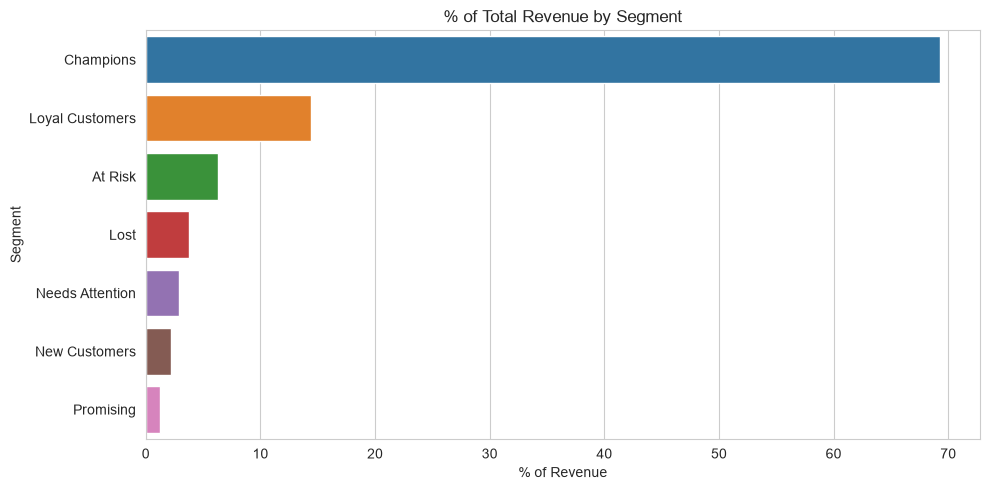

In [5]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=revenue_by_segment,
    x='Pct_of_Revenue',
    y='Segment',
    hue='Segment',
    legend=False
)

plt.title('% of Total Revenue by Segment')
plt.xlabel('% of Revenue')
plt.ylabel('Segment')
plt.tight_layout()

plt.savefig('../images/revenue_pct_by_segment.png', dpi=150)
plt.show()

In [6]:
segment_actions = {
    'Champions': 'Reward with loyalty perks, early access to new products, request referrals',
    'Loyal Customers': 'Upsell higher-value products, enroll in loyalty program',
    'New Customers': 'Onboarding offers, encourage second purchase',
    'Promising': 'Nurture with targeted recommendations, limited-time offers',
    'At Risk': 'Win-back campaigns, personalized discount, ask for feedback',
    'Needs Attention': 'Re-engagement email, remind of value/new arrivals',
    'Lost': 'Low-cost reactivation campaign or deprioritize spend here',
    'Others': 'Monitor, no immediate action needed'
}

revenue_by_segment['Recommended_Action'] = revenue_by_segment['Segment'].map(segment_actions)
revenue_by_segment

,Segment,Customer_Count,Total_Revenue,Pct_of_Customers,Pct_of_Revenue,Recommended_Action
1,Champions,1482,1.229314e+07,25.2,69.3,"Reward with loyalty perks, early access to new..."
3,Loyal Customers,1221,2.548938e+06,20.8,14.4,"Upsell higher-value products, enroll in loyalt..."
0,At Risk,353,1.126231e+06,6.0,6.3,"Win-back campaigns, personalized discount, ask..."
2,Lost,1523,6.671219e+05,25.9,3.8,Low-cost reactivation campaign or deprioritize...
4,Needs Attention,471,5.077446e+05,8.0,2.9,"Re-engagement email, remind of value/new arrivals"
5,New Customers,443,3.946386e+05,7.5,2.2,"Onboarding offers, encourage second purchase"
6,Promising,385,2.056168e+05,6.5,1.2,"Nurture with targeted recommendations, limited..."


In [7]:
cluster_value = rfm.groupby('Cluster_Label').agg(
    Customer_Count=('Customer ID', 'count'),
    Avg_Monetary=('Monetary', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Recency=('Recency', 'mean')
).round(1).sort_values('Avg_Monetary', ascending=False)

cluster_value

,Customer_Count,Avg_Monetary,Avg_Frequency,Avg_Recency
Cluster_Label,,,,
High-Value Loyal,2352,6619.5,12.6,51.2
Recent Low-Spend,3526,616.7,2.1,301.5


In [8]:
top_20_customers = rfm.sort_values('Monetary', ascending=False).head(20)[
    ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Segment', 'Cluster_Label']
]

top_20_customers

,Customer ID,Recency,Frequency,Monetary,Segment,Cluster_Label
5692,18102,1,145,608821.65,Champions,High-Value Loyal
2277,14646,2,151,528602.52,Champions,High-Value Loyal
1789,14156,10,156,313946.37,Champions,High-Value Loyal
2538,14911,1,398,295972.63,Champions,High-Value Loyal
5050,17450,8,51,246973.09,Champions,High-Value Loyal
1331,13694,4,143,196482.81,Champions,High-Value Loyal
5109,17511,3,60,175603.55,Champions,High-Value Loyal
4061,16446,1,2,168472.50,New Customers,High-Value Loyal
4295,16684,4,55,147142.77,Champions,High-Value Loyal
68,12415,24,28,144458.37,Champions,High-Value Loyal


In [9]:
final_export = rfm[[
    'Customer ID', 'Recency', 'Frequency', 'Monetary',
    'R_Score', 'F_Score', 'M_Score', 'RFM_Score',
    'Segment', 'Cluster', 'Cluster_Label'
]].copy()

final_export.columns = [
    'CustomerID', 'Recency', 'Frequency', 'Monetary',
    'R_Score', 'F_Score', 'M_Score', 'RFM_Score',
    'RFM_Segment', 'KMeans_Cluster', 'KMeans_Cluster_Label'
]

final_export.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment,KMeans_Cluster,KMeans_Cluster_Label
0,12346,326,12,77556.46,2,5,5,255,At Risk,0,High-Value Loyal
1,12347,2,8,5633.32,5,4,5,545,Champions,0,High-Value Loyal
2,12348,75,5,2019.40,3,4,4,344,Loyal Customers,0,High-Value Loyal
3,12349,19,4,4428.69,5,3,5,535,Loyal Customers,0,High-Value Loyal
4,12350,310,1,334.40,2,1,2,212,Lost,1,Recent Low-Spend


In [10]:
output_path = "../data/processed/customer_segments_final.csv"

final_export.to_csv(output_path, index=False)

print(f"Saved final deliverable to {output_path}")
print("Final shape:", final_export.shape)

Saved final deliverable to ../data/processed/customer_segments_final.csv
Final shape: (5878, 11)


In [11]:
output_path = "../data/processed/segment_summary_with_actions.csv"

revenue_by_segment.to_csv(output_path, index=False)

print("Saved segment summary with recommended actions ")

Saved segment summary with recommended actions 


In [12]:
print(f"Total customers analyzed: {rfm.shape[0]:,}")
print(f"Total revenue analyzed: £{total_revenue:,.2f}")
print(f"\nTop segment by revenue:")
print(revenue_by_segment.iloc[0][['Segment', 'Pct_of_Customers', 'Pct_of_Revenue']])

Total customers analyzed: 5,878
Total revenue analyzed: £17,743,429.18

Top segment by revenue:
Segment             Champions
Pct_of_Customers         25.2
Pct_of_Revenue           69.3
Name: 1, dtype: object
